# Environment

In [2]:
import os
os.chdir("..")

In [3]:
import pandas as pd
from sklearn.metrics import classification_report

from src.pipeline.llm import ModelConfig, PromptConfig, ChatTemplatePipeline

from src.utils.map import SYMPTOM_MAP
from src.utils.prompt import load_prompt, user_prompt

In [4]:
LABEL_CLASSES = list(SYMPTOM_MAP.values())

## Data Load

In [ ]:
df = pd.read_csv("./data/processed/amive.csv")

## Prompt Config

In [6]:
prompt_zero_shot_cfg = PromptConfig(
    system_prompt=load_prompt("./prompts/zero_shot.txt"),
    user_prompt=user_prompt,
    batch_size=1,
    text_col="TEXT",
)

In [7]:
prompt_few_shot_cfg = PromptConfig(
    system_prompt=load_prompt("./prompts/few_shot.txt"),
    user_prompt=user_prompt,
    batch_size=1,
    text_col="TEXT",
)

## Model Config

In [8]:
model_cfg = ModelConfig(
    model_name="Qwen_2.5-14B",
    model_path="./models/Qwen2.5-14B/",
    label_classes=LABEL_CLASSES,
    max_new_tokens=48,
    do_sample=False,
)

In [9]:
pipeline = ChatTemplatePipeline(model_cfg)

## Y_True

In [10]:
y_true = df[LABEL_CLASSES]

## Zero-Shot

In [11]:
zero_shot = pipeline.run(df, prompt_zero_shot_cfg, verbose=True)

INFO:accelerate.utils.modeling:We will use 90% of the memory on device 0 for storing the model, and 10% for the buffer to avoid OOM. You can set `max_memory` in to a higher value to use more memory (at your own risk).


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

DEBUG:src.pipeline.llm:idx=0 | out='{"labels":[3]}' | parser=3
DEBUG:src.pipeline.llm:idx=1 | out='{"labels":[2]}' | parser=2
DEBUG:src.pipeline.llm:idx=2 | out='{"labels":[1,6]}' | parser=1,6
DEBUG:src.pipeline.llm:idx=3 | out='{"labels":[1]}' | parser=1
DEBUG:src.pipeline.llm:idx=4 | out='{"labels":[1,5]}' | parser=1,5
DEBUG:src.pipeline.llm:idx=5 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=6 | out='{"labels":[1]}' | parser=1
DEBUG:src.pipeline.llm:idx=7 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=8 | out='{"labels":[6]}' | parser=6
DEBUG:src.pipeline.llm:idx=9 | out='{"labels":[2,4]}' | parser=2,4
DEBUG:src.pipeline.llm:idx=10 | out='{"labels":[2]}' | parser=2
DEBUG:src.pipeline.llm:idx=11 | out='{"labels":[1,3]}' | parser=1,3
DEBUG:src.pipeline.llm:idx=12 | out='{"labels":[5,9]}' | parser=5,9
DEBUG:src.pipeline.llm:idx=13 | out='{"labels":[1]}' | parser=1
DEBUG:src.pipeline.llm:idx=14 | out='{"labels":[1,4]}' | parser=1,4
DEBUG:src.pipeline.llm:idx=1

In [12]:
y_pred_zero_shot = zero_shot["encoded"]

In [13]:
print(classification_report(y_true, y_pred_zero_shot, zero_division=0, target_names=LABEL_CLASSES))

              precision    recall  f1-score   support

           1       0.50      0.83      0.62         6
           2       0.50      1.00      0.67         3
           3       1.00      0.50      0.67         4
           4       0.33      1.00      0.50         1
           5       0.50      1.00      0.67         2
           6       0.67      0.67      0.67         3
           7       0.00      0.00      0.00         1
           8       1.00      0.20      0.33         5
           9       0.00      0.00      0.00         0

   micro avg       0.53      0.64      0.58        25
   macro avg       0.50      0.58      0.46        25
weighted avg       0.67      0.64      0.56        25
 samples avg       0.54      0.62      0.55        25



## Few-Shot

In [14]:
few_shot = pipeline.run(df, prompt_few_shot_cfg, verbose=True)

DEBUG:src.pipeline.llm:idx=0 | out='{"labels":[3]}' | parser=3
DEBUG:src.pipeline.llm:idx=1 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=2 | out='{"labels":[1]}' | parser=1
DEBUG:src.pipeline.llm:idx=3 | out='{"labels":[6]}' | parser=6
DEBUG:src.pipeline.llm:idx=4 | out='{"labels":[1,5]}' | parser=1,5
DEBUG:src.pipeline.llm:idx=5 | out='{"labels":[7]}' | parser=7
DEBUG:src.pipeline.llm:idx=6 | out='{"labels":[1]}' | parser=1
DEBUG:src.pipeline.llm:idx=7 | out='{"labels":[0]}' | parser=
DEBUG:src.pipeline.llm:idx=8 | out='{"labels":[6]}' | parser=6
DEBUG:src.pipeline.llm:idx=9 | out='{"labels":[2]}' | parser=2
DEBUG:src.pipeline.llm:idx=10 | out='{"labels":[2]}' | parser=2
DEBUG:src.pipeline.llm:idx=11 | out='{"labels":[1,3]}' | parser=1,3
DEBUG:src.pipeline.llm:idx=12 | out='{"labels":[8]}' | parser=8
DEBUG:src.pipeline.llm:idx=13 | out='{"labels":[1]}' | parser=1
DEBUG:src.pipeline.llm:idx=14 | out='{"labels":[1,4]}' | parser=1,4
DEBUG:src.pipeline.llm:idx=15 | out='{"l

In [15]:
y_pred_few_shot = few_shot["encoded"]

In [16]:
print(classification_report(y_true, y_pred_few_shot, zero_division=0, target_names=LABEL_CLASSES))

              precision    recall  f1-score   support

           1       0.50      0.67      0.57         6
           2       1.00      1.00      1.00         3
           3       1.00      0.50      0.67         4
           4       1.00      1.00      1.00         1
           5       0.33      0.50      0.40         2
           6       0.67      0.67      0.67         3
           7       1.00      1.00      1.00         1
           8       1.00      0.40      0.57         5
           9       0.00      0.00      0.00         0

   micro avg       0.70      0.64      0.67        25
   macro avg       0.72      0.64      0.65        25
weighted avg       0.79      0.64      0.67        25
 samples avg       0.62      0.62      0.59        25



# Analysis

DEBUG:matplotlib:matplotlib data path: /home/leo/.venv/lib/python3.12/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/home/leo/.config/matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is linux


DEBUG:matplotlib:CACHEDIR=/home/leo/.cache/matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /home/leo/.cache/matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/leo/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/home/leo/.venv/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=400, stretch='normal', size='scala

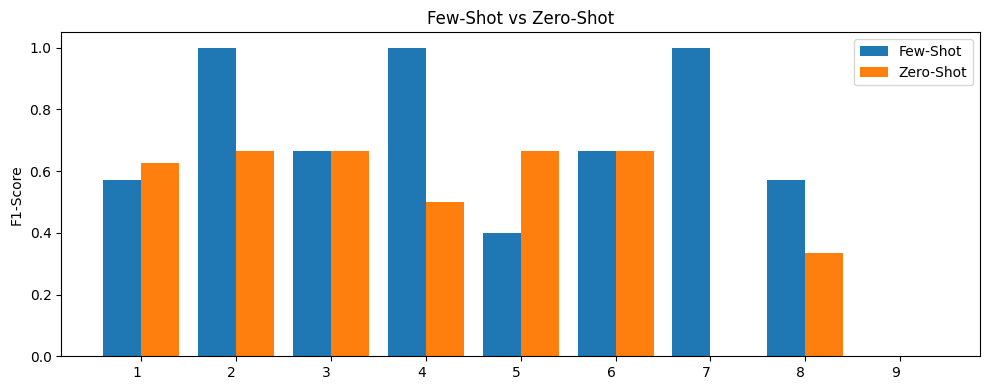

In [17]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

few  = [f1_score(y_true[l], y_pred_few_shot[l],  zero_division=0) for l in LABEL_CLASSES]
zero = [f1_score(y_true[l], y_pred_zero_shot[l], zero_division=0) for l in LABEL_CLASSES]

x = range(len(LABEL_CLASSES))
plt.figure(figsize=(10, 4))
plt.bar([i - 0.2 for i in x], few,  0.4, label="Few-Shot")
plt.bar([i + 0.2 for i in x], zero, 0.4, label="Zero-Shot")
plt.xticks(list(x), LABEL_CLASSES, ha="right")
plt.ylabel("F1-Score")
plt.title("Few-Shot vs Zero-Shot")
plt.legend()
plt.tight_layout()
plt.show()